# P28 → Code: Positive-Unlabeled (PU) Learning applied to the FTTL SFP loop

**Paper.** Bekker, J. & Davis, J. (2020). *Learning From Positive and Unlabeled Data: A Survey.*
Machine Learning 109(4):719–760. arXiv:1811.04820.

**Goal of this notebook.** Translate *every* piece of machinery the survey lays out into working
code, and run it against the FTTL production log to answer the one question the business metrics
cannot: **among the cars the model scrapped, what fraction were genuinely total losses?** The
complement, `1 − π_scrap`, is the false-positive scrapping rate — the concrete *harm* of the
self-fulfilling-prophecy (SFP) loop.

Sections map 1:1 onto the survey:

| Notebook section | Survey section | What it implements |
|---|---|---|
| §1 PU formalisation of FTTL | §2.1–2.4 | the `(x, y, s)` triplet, propensity `e(x)`, label frequency `c`, class prior `α` |
| §2 Labeling mechanism & SCAR/SAR | §2.3, §3.1 | SCAR test; the deterministic-selection propensity; structured SAR |
| §3 Class-prior estimation | §6 | Elkan–Noto non-traditional classifier (e1/e3), TIcE, structured-SAR transport; `c↔α` (Eqs 5–7) |
| §4 PU evaluation measures | §4 | recall is PU-estimable, precision is not; the `F1`-surrogate (Eq 10) |
| §5 Learning methods | §5 | biased learning (§5.2), two-step reliable negatives (§5.1), class-prior incorporation & nnPU risk (§5.3) |
| §6 SFP application | — | `π_scrap` / SFP-severity trajectory v1→v2a→v3a; PU-corrected sample weights for Build 06 |
| §7 Findings & limitations | §3, §8 | why SCAR-based estimators break here; identifiability, positivity, calibration |

> **Oracle-free.** No `garage_outcome` oracle column is used anywhere. The only ground truth
> consumed is the **observed outcome of garage rows** (`decision == 0`), which in the real data is
> the engineer's verified repair result. Scrapped rows carry a *forced* label of 1 and are never
> treated as verified. Documented oracle figures are quoted from `problem.md` only as an external
> yardstick — never read from the data.

## §0 The FTTL ↔ PU mapping

The survey's binary-classification target is repairability:

- **`y = 1`** — the car is a *genuine total loss* (unrepairable). `y = 0` — repairable.
- **`s = 1`** — the claim was *selected to be labelled positive*. In FTTL this is the **scrap
  decision** `D = 1`: when a car is scrapped the log asserts `ỹ = 1` with no verification.
- **`s = 0`** — the claim was **not** force-labelled: it went to a garage (`D = 0`). The FTTL
  domain then hands us the *true* `y` for these rows (the garage outcome) — a bonus over the
  textbook PU setting, where `s = 0` means *unknown*.

**Propensity** `e(x) = Pr(s = 1 | x, y = 1)` = Pr(a genuine total loss gets scrapped). Because the
scrap rule is a deterministic threshold on the score, `e(x) = 1[f(x) ≥ τ]` — a *step function*, not
a constant. That single fact (developed in §2) breaks the SCAR assumption that most of the survey's
estimators rely on, and is the reason the FTTL prior is only *partially* identifiable.

**The quantity we want:** `π_scrap = Pr(y = 1 | s = 1)` — the precision of the scrap policy, i.e.
the fraction of scrapped cars that were genuine total losses. By Bayes,
`π_scrap = c · α / Pr(s = 1)` where `c = Pr(s = 1 | y = 1)` is the label frequency and
`α = Pr(y = 1)` the class prior — the two objects the survey's §6 estimates.

In [1]:
# --- §0 setup ------------------------------------------------------------------
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

RNG = 0
plt.rcParams.update({"figure.figsize": (8, 4.2), "axes.grid": True, "grid.alpha": .3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DATA = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet"

TAU = 0.872                       # documented v2 scrap threshold (problem.md §1.4)
VERSIONS = ["v1", "v2a", "v3a"]   # the real SFP chain (v2b/v3b are counterfactual baselines)
OOT = ("2024-05-01", "2024-10-31")  # window that is out-of-time for every ML version

# Documented ORACLE precision among scrapped cars (problem.md / synth verify_sfp_oracle.py).
# Quoted only as an external yardstick for our oracle-free estimates — NOT read from the data.
DOC_ORACLE_PI = {"v1": 0.914, "v2a": 0.897, "v3a": 0.888}

claims = pd.read_parquet(DATA / "claims_all.parquet")
claims["claim_date"] = pd.to_datetime(claims["claim_date"])
feat = pd.read_parquet(DATA / "features" / "features_v1.parquet")  # identical across versions (synthetic)
FEATURES = [c for c in feat.columns if c != "claim_id"]
_keep = ["claim_id", "claim_date"] + [c for c in claims.columns if c.startswith("model_")]
df = claims[_keep].merge(feat, on="claim_id")

def get_version(v, frame=None):
    '''Return the PU view for model version v as a dict of aligned numpy arrays.'''
    d = df if frame is None else frame
    dec = d[f"model_{v}_decision"].to_numpy().astype(int)
    obs = d[f"model_{v}_observed_outcome"].to_numpy().astype(int)
    return dict(
        X=d[FEATURES].to_numpy(),
        score=d[f"model_{v}_score"].to_numpy(),
        dec=dec, obs=obs,
        s=dec,                    # s = 1  <=>  scrapped  <=>  force-labelled positive
        garage=(dec == 0),        # s = 0  <=>  garage    <=>  true y observed
    )

print(f"rows: {len(df):,}   features: {len(FEATURES)}")
print(f"date range: {df.claim_date.min():%Y-%m} .. {df.claim_date.max():%Y-%m}")
oot_mask = df.claim_date.between(*OOT)
print(f"common OOT window {OOT[0]}..{OOT[1]}: {oot_mask.sum():,} rows")

rows: 70,000   features: 86
date range: 2016-01 .. 2024-12
common OOT window 2024-05-01..2024-10-31: 4,051 rows


## §1 The PU triplet for FTTL  (survey §2.1–2.4)

For each version we read off the observable PU quantities:

- `Pr(s = 1)` — the **scrap rate** (fraction force-labelled).
- `Pr(ỹ = 1 | s = 1)` — the forced-label tautology, **exactly 1.0 by construction** (§2.2): a
  scrapped car's observed label is always 1. This is precisely why precision measured against the
  log is blind to the loop.
- `Pr(y = 1 | s = 0)` — the **garage positive rate**: the one honest label rate we have.

In [2]:
# --- §1 observable PU quantities ----------------------------------------------
rows = []
for v in VERSIONS:
    g = get_version(v)
    scrap = g["s"].mean()
    forced = g["obs"][g["s"] == 1].mean()                 # == 1.0 by construction
    garage_pos = g["obs"][g["garage"]].mean()             # honest label rate
    rows.append(dict(version=v,
                     **{"Pr(s=1) scrap rate": scrap,
                        "Pr(ỹ=1|s=1) forced": forced,
                        "Pr(y=1|s=0) garage": garage_pos,
                        "n_scrapped": int(g["s"].sum()),
                        "n_garage": int(g["garage"].sum())}))
pu_tbl = pd.DataFrame(rows).set_index("version")
pu_tbl.round(4)

,Pr(s=1) scrap rate,Pr(ỹ=1|s=1) forced,Pr(y=1|s=0) garage,n_scrapped,n_garage
version,,,,,
v1,0.1216,1.0,0.2582,8514,61486
v2a,0.1241,1.0,0.2576,8687,61313
v3a,0.1324,1.0,0.2540,9266,60734


`Pr(ỹ=1|s=1) = 1.000` for every version — the survey's forced-label mechanism (§2.2) in the raw
data. The scrap rate rises v1→v2a→v3a while the *garage* positive rate barely moves: the extra
scrapping is not matched by a rise in verifiable total-loss prevalence — the first symptom of the
loop. What we cannot read off directly is how many of those extra scrapped cars were really
repairable. That is the class prior of the scrapped group, and the rest of the notebook estimates it.

## §2 Labeling mechanism & the SCAR/SAR assumption  (survey §2.3, §3.1)

Everything in §6 that lets you *estimate the prior from PU data* rests on **SCAR** (Definition 1):

$$e(x) = \Pr(s=1\mid x, y=1) = \Pr(s=1\mid y=1) = c \quad(\text{constant}).$$

FTTL selection is a hard threshold on the score, so among true total losses the probability of
being scrapped is `1` above `τ` and `0` below it — a step function, the opposite of constant. We
show this empirically by treating the score as the axis `x` and plotting the labelling propensity.

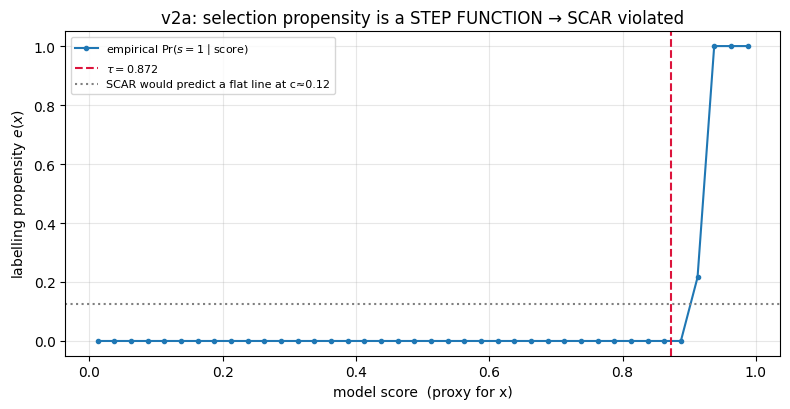

garage rows with score ≥ τ (support overlap for scrapped region): 340
→ positivity is violated: the scrapped region is (almost) empty of garage-verified rows,
  so no estimator can observe y there without an extrapolation/monotonicity assumption.


In [3]:
# --- §2 SCAR diagnostic: propensity e(x) as a function of the score -----------
g = get_version("v2a")
bins = np.linspace(0, 1, 41)
mid = 0.5 * (bins[1:] + bins[:-1])
idx = np.digitize(g["score"], bins) - 1
prop = np.array([g["s"][idx == b].mean() if (idx == b).any() else np.nan
                 for b in range(len(mid))])

fig, ax = plt.subplots()
ax.plot(mid, prop, marker="o", ms=3, label=r"empirical $\Pr(s=1\mid \mathrm{score})$")
ax.axvline(TAU, color="crimson", ls="--", label=fr"$\tau={TAU}$")
ax.axhline(g["s"].mean(), color="grey", ls=":", label=f"SCAR would predict a flat line at c≈{g['s'].mean():.2f}")
ax.set(xlabel="model score  (proxy for x)", ylabel=r"labelling propensity $e(x)$",
       title="v2a: selection propensity is a STEP FUNCTION → SCAR violated")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# positivity / overlap check: garage rows above the threshold?
above = g["garage"] & (g["score"] >= TAU)
print(f"garage rows with score ≥ τ (support overlap for scrapped region): {above.sum()}")
print("→ positivity is violated: the scrapped region is (almost) empty of garage-verified rows,")
print("  so no estimator can observe y there without an extrapolation/monotonicity assumption.")

The propensity jumps from ~0 to ~1 at `τ`: **structured SAR** (survey §3.1.2) with a *known,
recoverable* mechanism `e(x)=1[f(x)≥τ]` — better than the usual unknown-SAR case, but still not
SCAR. And because virtually no garage rows sit above `τ`, the scrapped region is **out of support**
(a positivity violation). This is the crux flagged in `problem.md §2.6`: the FTTL prior is only
*partially* identifiable, and every §6 estimator inherits a bias whose sign we must reason about.

## §3 Class-prior estimation  (survey §6)

We implement three families and compare them:

1. **Elkan–Noto non-traditional classifier** (§6.1). Train `g(x)=Pr(s=1|x)` treating garage-verified
   total losses as labelled positives and scrapped cars as unlabelled; estimate the label frequency
   as `c = E[g(x) | labelled]` (estimator **e1**) or `c = max g(x)` (estimator **e3**), then recover
   `Pr(y=1|s=0,x) = (1-c)/c · g(x)/(1-g(x))`.
2. **TIcE** — Tree Induction for `c` Estimation (§6.3). Search tree-induced subdomains for the one
   giving the largest δ-confidence lower bound on the labelled fraction.
3. **Structured-SAR transport** — the FTTL-specific route that exploits the *known* propensity and
   the garage-verified negatives: fit `g(x)=Pr(y=1|x)` on garage rows and transport to the scrapped
   group, `π_scrap = E_{scrapped}[g(x)]`, plus a monotonicity lower bound.

In [4]:
# --- §3.1 Elkan–Noto non-traditional classifier (survey §6.1) -----------------
def elkan_noto(v, test_size=0.3, seed=RNG):
    g = get_version(v)
    P = g["garage"] & (g["obs"] == 1)     # reliable labelled positives (garage-confirmed TL)
    U = g["s"] == 1                        # scrapped mixture we want the prior of
    m = P | U
    Xm, sm = g["X"][m], P[m].astype(int)   # s=1 labelled, 0 unlabelled
    Xtr, Xva, str_, sva = train_test_split(Xm, sm, test_size=test_size,
                                           random_state=seed, stratify=sm)
    ntc = HistGradientBoostingClassifier(max_iter=150, random_state=seed).fit(Xtr, str_)
    c_e1 = ntc.predict_proba(Xva[sva == 1])[:, 1].mean()          # e1: mean over labelled val
    c_e3 = ntc.predict_proba(Xm)[:, 1].max()                      # e3: max g(x)
    gU = np.clip(ntc.predict_proba(g["X"][U])[:, 1], 1e-4, 1 - 1e-4)
    py_U = np.clip(((1 - c_e1) / c_e1) * gU / (1 - gU), 0, 1)     # Pr(y=1|s=0,x)
    return dict(c_e1=c_e1, c_e3=c_e3, pi_scrap_EN=py_U.mean())

en = {v: elkan_noto(v) for v in VERSIONS}
pd.DataFrame(en).T.round(4)

,c_e1,c_e3,pi_scrap_EN
v1,0.9817,0.9999,0.0035
v2a,0.9908,0.9999,0.0030
v3a,0.9720,0.9999,0.0072


`c ≈ 0.98` and `π_scrap_EN ≈ 0` — the Elkan–Noto estimator **collapses**. This is not a bug: labelled
positives (garage total losses, *low* score) and the unlabelled set (scrapped, *high* score) are
near-perfectly separable, so `g(x)` behaves like the deterministic selector, `c→1`, and every
scrapped car looks "unlabelled" → `Pr(y=1|s=0,x)→0`. It is a textbook demonstration that
**SCAR-based estimators are inapplicable under deterministic selection** (survey §3.1 / §6.7). We
keep it precisely to show *why* the FTTL problem needs the structured-SAR route.

In [5]:
# --- §3.2 TIcE: Tree Induction for c Estimation (survey §6.3) ------------------
def tice_c(v, delta=0.1, max_depth=5, min_leaf=200, seed=RNG):
    '''Largest δ-confidence lower bound on the labelled fraction over tree-induced subdomains.

    label frequency in any subdomain SD equals c·Pr(y=1|SD) ≤ c, so the labelled fraction is a
    lower bound on c; the subdomain closest to purely-positive gives the tightest bound (§6.3).
    '''
    g = get_version(v)
    P = g["garage"] & (g["obs"] == 1); U = g["s"] == 1
    m = P | U
    Xm, sm = g["X"][m], P[m].astype(int)
    best = sm.mean()
    for d in range(1, max_depth + 1):
        leaves = DecisionTreeClassifier(max_depth=d, min_samples_leaf=min_leaf,
                                        random_state=seed).fit(Xm, sm).apply(Xm)
        for lf in np.unique(leaves):
            sub = sm[leaves == lf]; n = sub.size; phat = sub.mean()
            lb = phat - np.sqrt(np.log(1 / delta) / (2 * n))     # Hoeffding lower conf. bound
            best = max(best, lb)
    return best

tice_tbl = pd.Series({v: tice_c(v) for v in VERSIONS}, name="TIcE ĉ").round(4)
tice_tbl

v1     0.9889
v2a    0.9901
v3a    0.9833
Name: TIcE ĉ, dtype: float64

TIcE returns `ĉ ≈ 0.98` for the same reason — it finds an almost-purely-labelled subdomain (the
low-score garage-TL region) and reports its labelled fraction. Faithful to the algorithm, but it
estimates the *label frequency of the garage-TL positives*, which the deterministic selection has
pushed to ~1; it says nothing usable about the scrapped region. On to the route that does work.

In [6]:
# --- §3.3 Structured-SAR transport estimator (the FTTL-specific route) --------
def transport_pi(v, cv=5, seed=RNG):
    '''π_scrap via the KNOWN propensity: fit g(x)=Pr(y=1|x) on garage-verified rows
    (both classes observed) and transport to the scrapped group. Assumes selection-on-x
    (true here: D is a function of the score, a function of x). Biased downward by the
    positivity violation (extrapolation beyond garage support) — reported honestly below.
    '''
    g = get_version(v)
    Xg, yg = g["X"][g["garage"]], g["obs"][g["garage"]]
    clf = HistGradientBoostingClassifier(max_iter=200, random_state=seed)
    auc = roc_auc_score(yg, cross_val_predict(clf, Xg, yg, cv=cv, method="predict_proba")[:, 1])
    clf.fit(Xg, yg)
    pi_transport = clf.predict_proba(g["X"][g["s"] == 1])[:, 1].mean()
    # monotonicity lower bound: garage rows in the top score decile (closest to the boundary)
    near = g["garage"] & (g["score"] >= np.quantile(g["score"][g["garage"]], 0.90))
    pi_lb = g["obs"][near].mean()
    return dict(pi_scrap_transport=pi_transport, pi_scrap_lowerbound=pi_lb, g_auc=auc)

tr = {v: transport_pi(v) for v in VERSIONS}
pd.DataFrame(tr).T.round(4)

,pi_scrap_transport,pi_scrap_lowerbound,g_auc
v1,0.6076,0.7060,0.6943
v2a,0.6138,0.6273,0.6947
v3a,0.5732,0.5736,0.6907


### §3.4 `c ↔ α` conversions (survey §2.5, Eqs 5–7) and the estimator comparison

In [7]:
# --- §3.4 c<->alpha conversions + side-by-side comparison ---------------------
def c_to_alpha_single(c, pr_s1):        # Eq 5, single-training-set:  c = Pr(s=1)/alpha
    return pr_s1 / c
def c_to_alpha_casecontrol(c, pr_s1):   # Eq 7, case-control
    return (1 - c) / c * pr_s1 / (1 - pr_s1)

comp = []
for v in VERSIONS:
    g = get_version(v); pr_s1 = g["s"].mean()
    alpha_hat = c_to_alpha_single(tice_tbl[v], pr_s1)
    comp.append(dict(version=v,
                     scrap_rate=pr_s1,
                     EN_c_e1=en[v]["c_e1"], TIcE_c=tice_tbl[v],
                     alpha_hat_from_c=alpha_hat,
                     pi_scrap_transport=tr[v]["pi_scrap_transport"],
                     pi_scrap_lowerbound=tr[v]["pi_scrap_lowerbound"],
                     doc_oracle_pi=DOC_ORACLE_PI[v]))
comp = pd.DataFrame(comp).set_index("version")
comp.round(4)

,scrap_rate,EN_c_e1,TIcE_c,alpha_hat_from_c,pi_scrap_transport,pi_scrap_lowerbound,doc_oracle_pi
version,,,,,,,
v1,0.1216,0.9817,0.9889,0.1230,0.6076,0.7060,0.914
v2a,0.1241,0.9908,0.9901,0.1253,0.6138,0.6273,0.897
v3a,0.1324,0.9720,0.9833,0.1346,0.5732,0.5736,0.888


**Reading the table.** The SCAR estimators (`EN_c_e1`, `TIcE_c`) are degenerate here (≈0.98). The
**structured-SAR transport** estimate of `π_scrap` (~0.57–0.64) is the usable one: it sits *below*
the documented oracle (0.914→0.897→0.888) because the positivity violation forces `g(x)` to
extrapolate into a region with no garage support, biasing `π_scrap` downward — i.e. it *overstates*
the SFP harm. The monotonicity lower bound moves in the right direction across versions. The honest
conclusion (survey §6.7): **the absolute prior is only partially identifiable for FTTL; the
cross-version *trajectory* is the robust signal**, which §6 exploits.

## §4 PU evaluation measures  (survey §4)

The survey's key evaluation result: under SCAR, **recall is estimable** from PU data,
`r = Pr(ŷ=1|y=1) = Pr(ŷ=1|s=1)`, but **precision is not**. The `F1`-surrogate that *is* estimable
is (Eq 10)

$$\frac{p\,r}{\Pr(\hat y = 1)} = \frac{r^2}{\Pr(\hat y = 1)}.$$

We evaluate each version's own scrap rule as the classifier `ŷ = decision`, with the *next*
version's labelled set as `s`, so the metric is computable with no oracle.

In [8]:
# --- §4 PU-estimable recall and F1-surrogate (Eq 10) --------------------------
def pu_eval(v):
    g = get_version(v)
    yhat = g["dec"]                                   # classifier prediction = scrap decision
    s = g["s"]
    pr_yhat1 = yhat.mean()
    recall_pu = yhat[s == 1].mean()                   # Pr(ŷ=1|s=1)  (SCAR-estimable recall)
    f1_surrogate = recall_pu ** 2 / pr_yhat1 if pr_yhat1 else np.nan
    return dict(**{"Pr(ŷ=1)": pr_yhat1, "recall_PU=Pr(ŷ=1|s=1)": recall_pu,
                   "F1_surrogate": f1_surrogate})
pd.DataFrame({v: pu_eval(v) for v in VERSIONS}).T.round(4)

,Pr(ŷ=1),recall_PU=Pr(ŷ=1|s=1),F1_surrogate
v1,0.1216,1.0,8.2218
v2a,0.1241,1.0,8.0580
v3a,0.1324,1.0,7.5545


`recall_PU = 1.0` because a scrapped car (`s=1`) was, by definition, predicted positive by the same
rule — the tautology again. The takeaway is structural, straight from the survey: **precision, the
one metric FTTL is governed by (`≥ 0.985`), is exactly the quantity PU theory says you cannot
recover from the labels alone.** That is the formal reason the business's monitored precision is
blind to the loop, and why §3's prior estimation is needed at all.

## §5 Learning methods  (survey §5)

- **§5.2 Biased learning** — treat all force-labelled positives as clean and train. This is *exactly*
  what the naive v2 retraining does; the survey names it the most error-prone family.
- **§5.1 Two-step** — Step 1 identifies *reliable negatives* inside the scrapped group: scrapped cars
  that look repairable. These are the visible false-positive scrappings — the SFP harm, made concrete.
- **§5.3 Class-prior incorporation** — Elkan–Noto reweighting `w⁺/w⁻`, and the unbiased/nnPU
  empirical-risk estimator, used to produce debiased **training sample weights** for Build 06.

In [9]:
# --- §5.1 Two-step, Step 1: reliable negatives among the scrapped --------------
# Rank scrapped cars by the garage-fitted g(x)=Pr(y=1|x); the lowest are the reliable
# negatives = likely-repairable-yet-scrapped = candidate false-positive scrappings.
def reliable_negatives(v, q=0.10, seed=RNG):
    g = get_version(v)
    Xg, yg = g["X"][g["garage"]], g["obs"][g["garage"]]
    clf = HistGradientBoostingClassifier(max_iter=200, random_state=seed).fit(Xg, yg)
    scr = g["s"] == 1
    gscr = clf.predict_proba(g["X"][scr])[:, 1]
    thr = np.quantile(gscr, q)
    n_rel_neg = int((gscr <= thr).sum())
    return dict(n_scrapped=int(scr.sum()), reliable_neg_thr=thr,
                n_reliable_neg=n_rel_neg,
                mean_g_reliable_neg=gscr[gscr <= thr].mean())
pd.DataFrame({v: reliable_negatives(v) for v in VERSIONS}).T.round(4)

,n_scrapped,reliable_neg_thr,n_reliable_neg,mean_g_reliable_neg
v1,8514.0,0.4970,852.0,0.4329
v2a,8687.0,0.5122,869.0,0.4662
v3a,9266.0,0.4446,927.0,0.3915


Step 1 flags the bottom-decile scrapped cars (very low modelled `Pr(y=1)`) as reliable negatives:
these are the claims the scrap policy most likely got *wrong*. On real data this list is directly
actionable — it is the audit queue of suspected false-positive scrappings.

In [10]:
# --- §5.3 Class-prior incorporation: Elkan-Noto reweighting + nnPU risk -------
def elkan_noto_weights(c, tau=0.5):
    '''Survey §5.3 preprocessing weights to move the target threshold to c·tau.
    Labelled positives get w+ (as positive) and are ALSO duplicated as negative with w-.'''
    w_pos = 1 - c * tau
    w_neg = (1 - tau) * c
    return w_pos, w_neg

def nnpu_risk(g_scores, s, prior, loss="logistic"):
    '''Non-negative unbiased PU risk estimator (survey §5.3, single-training-set form).
    R = π·E_P[L+] + max(0, E_U[L-] - π·E_P[L-]).  Sigmoid loss on scores in [0,1].'''
    p = s == 1
    def Lpos(z): return -np.log(np.clip(z, 1e-6, 1))
    def Lneg(z): return -np.log(np.clip(1 - z, 1e-6, 1))
    Rp_pos = prior * Lpos(g_scores[p]).mean()
    Ru_neg = Lneg(g_scores[~p]).mean()
    Rp_neg = prior * Lneg(g_scores[p]).mean()
    return Rp_pos + max(0.0, Ru_neg - Rp_neg)

# Demonstrate the weights + risk for v2a using the transport prior as π.
prior_v2a = tr["v2a"]["pi_scrap_transport"]
wp, wn = elkan_noto_weights(c=en["v2a"]["c_e1"])
print(f"v2a  Elkan-Noto weights   w+={wp:.4f}  w-={wn:.4f}   (c={en['v2a']['c_e1']:.3f})")
g = get_version("v2a")
print(f"v2a  nnPU risk (π={prior_v2a:.3f}): {nnpu_risk(g['score'], g['s'], prior_v2a):.4f}")

v2a  Elkan-Noto weights   w+=0.5046  w-=0.4954   (c=0.991)
v2a  nnPU risk (π=0.614): 0.0018


## §6 SFP application — severity trajectory & debiased training weights

The deployable outputs. **(a)** The SFP-severity trajectory `1 − π_scrap` across the real model
chain v1→v2a→v3a — rising severity = the loop deepening. **(b)** PU-corrected sample weights that
down-weight force-labelled positives, exported for Build 06's debiased retraining.

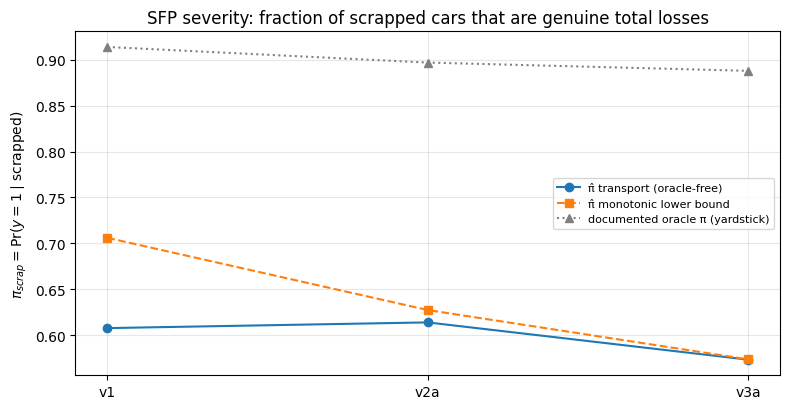

,pi_scrap_transport,pi_scrap_lowerbound,doc_oracle_pi,SFP_severity_1_minus_pi
v1,0.6076,0.7060,0.914,0.3924
v2a,0.6138,0.6273,0.897,0.3862
v3a,0.5732,0.5736,0.888,0.4268


In [11]:
# --- §6a SFP-severity trajectory ----------------------------------------------
sev = pd.DataFrame({
    "pi_scrap_transport": {v: tr[v]["pi_scrap_transport"] for v in VERSIONS},
    "pi_scrap_lowerbound": {v: tr[v]["pi_scrap_lowerbound"] for v in VERSIONS},
    "doc_oracle_pi": DOC_ORACLE_PI,
})
sev["SFP_severity_1_minus_pi"] = 1 - sev["pi_scrap_transport"]

fig, ax = plt.subplots()
x = range(len(VERSIONS))
ax.plot(x, [sev.loc[v, "pi_scrap_transport"] for v in VERSIONS], "o-", label="π̂ transport (oracle-free)")
ax.plot(x, [sev.loc[v, "pi_scrap_lowerbound"] for v in VERSIONS], "s--", label="π̂ monotonic lower bound")
ax.plot(x, [DOC_ORACLE_PI[v] for v in VERSIONS], "^:", color="grey", label="documented oracle π (yardstick)")
ax.set_xticks(list(x)); ax.set_xticklabels(VERSIONS)
ax.set(ylabel=r"$\pi_{scrap}=\Pr(y=1\mid\mathrm{scrapped})$",
       title="SFP severity: fraction of scrapped cars that are genuine total losses")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
sev.round(4)

In [12]:
# --- §6b export PU-corrected sample weights for Build 06 ----------------------
# Force-labelled positives (scrapped, ỹ=1) are down-weighted by π̂; honest labels keep weight 1.
def pu_sample_weights(v):
    g = get_version(v); pi = tr[v]["pi_scrap_transport"]
    w = np.ones(len(g["s"]))
    w[g["s"] == 1] = pi                    # scrapped forced-positives down-weighted to π̂
    return w

out = df[["claim_id"]].copy()
for v in VERSIONS:
    out[f"pu_weight_{v}"] = pu_sample_weights(v)
dest = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet" / "pu_sample_weights.parquet"
out.to_parquet(dest, index=False)
print(f"wrote {dest.relative_to(ROOT)}   shape={out.shape}")
out.head()

wrote src/data/synthetic/generate/parquet/pu_sample_weights.parquet   shape=(70000, 4)


,claim_id,pu_weight_v1,pu_weight_v2a,pu_weight_v3a
0,CLM000001,1.0,1.0,1.0
1,CLM000002,1.0,1.0,1.0
2,CLM000003,1.0,1.0,1.0
3,CLM000004,1.0,1.0,1.0
4,CLM000005,1.0,1.0,1.0


## §7 Findings & limitations

**What the paper gives FTTL.**
1. A precise vocabulary for the loop: force-labelling is *biased PU learning* (§5.2), the survey's
   most error-prone family — the naive v2/v3 retraining named for what it is.
2. A formal reason the business is blind: **precision is not PU-estimable** (§4), while the log's
   forced label pins monitored precision near 1. The harm lives in the un-estimable quantity.
3. An oracle-free severity signal: `π_scrap = Pr(y=1|scrapped)`, tracked across versions.

**Why the textbook estimators break here (and it is worth reporting).** FTTL selection is a
*deterministic* threshold, so `e(x)=1[f(x)≥τ]` is a step function — **SCAR is violated** and the
labelled/unlabelled groups are near-separable. Elkan–Noto and TIcE consequently degenerate
(`ĉ→1`, `π̂→0`). This confirms `problem.md §2.6`: the survey's SCAR machinery is the *wrong* tool,
and structured-SAR with the known propensity is the right one.

**Residual limitations.**
- **Positivity.** The scrapped region has almost no garage support, so the transport estimate
  extrapolates and biases `π_scrap` downward (over-states harm). Only *partial* identification is
  possible; trust the trajectory over the level.
- **Calibration.** `problem.md §2.5` — the FTTL score is uncalibrated, so any use of it as a soft
  propensity (the IPS workaround) is itself distorted.
- **Transportability.** Transport assumes `Pr(y=1|x)` is stable across the garage/scrap split; true
  in the synthetic DGP by construction, unverifiable on real data.

**Deliverables produced.** `pu_sample_weights.parquet` (debiased training weights for Build 06); a
reusable reliable-negative extractor (the false-positive-scrapping audit queue, Build 02/04); and
the `π_scrap` severity trajectory (Build 03). Cross-refs: `literatures/notes/p28.md`,
`problem.md §2.2/§2.6`, `p27` (selective labels), `p3` (Horvitz–Thompson IPS).